In [38]:
import os
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms

In [2]:
synth_ds = datasets.ImageFolder(
    "/workspace/alvin/SAR_ML/data/SAMPLE/png_images/qpm/synth",
    transforms.ToTensor()
)
meas_ds = datasets.ImageFolder(
    "/workspace/alvin/SAR_ML/data/SAMPLE/png_images/qpm/real",
    transforms.ToTensor()
)

In [9]:
synth_ds[0][0].shape  # Check the shape of the first image in the synthetic dataset

torch.Size([3, 128, 128])

In [22]:
Total = 0

for i in range(len(synth_ds)):
    if ((synth_ds[i][0][0] == synth_ds[i][0][1]).all()) and ((synth_ds[i][0][0] == synth_ds[i][0][2]).all()):
        Total += 1

print(Total == len(synth_ds))

True


In [31]:
synth_vals = []

for i in range(len(synth_ds)):
    u, sigma = synth_ds[i][0][0].mean(), synth_ds[i][0][0].std()
    synth_vals.append((u.item(), sigma.item()))

In [23]:
Total = 0

for i in range(len(meas_ds)):
    if ((meas_ds[i][0][0] == meas_ds[i][0][1]).all()) and ((meas_ds[i][0][0] == meas_ds[i][0][2]).all()):
        Total += 1

print(Total == len(meas_ds))

True


In [32]:
meas_vals = []

for i in range(len(meas_ds)):
    u, sigma = meas_ds[i][0][0].mean(), meas_ds[i][0][0].std()
    meas_vals.append((u.item(), sigma.item()))

In [39]:
np.arange(0, 1, 0.01)

array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
       0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
       0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
       0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
       0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
       0.99])

(array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,
         0.,  3.,  2.,  0.,  0.,  2.,  0.,  1.,  0.

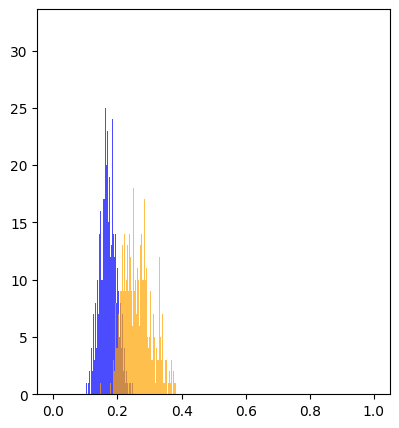

In [42]:
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(1, 2, 1)
ax1.hist([val[0] for val in synth_vals], bins = np.arange(0, 1, 0.001), alpha=0.7, label='Synthetic', color='blue')
ax1.hist([val[0] for val in meas_vals], bins = np.arange(0, 1, 0.001), alpha=0.7, label='Measured', color='orange')